# Día 9 · Unidad 10 — Estadística aplicada (II): distribuciones de probabilidad con SciPy

**Objetivos de aprendizaje**
- Reconocer la API común de `scipy.stats` para cualquier distribución: `pdf`/`pmf`, `cdf`, `ppf`, `rvs`.
- Trabajar con la distribución **normal** (continua): densidad, función de distribución, simulación, ajuste de parámetros con `.fit()`.
- Trabajar con la distribución **binomial** (discreta): probabilidad puntual, acumulada, simulación.
- Trabajar con la distribución de **Poisson** (discreta): conteos de eventos raros, simulación.
- Elegir la distribución adecuada según el tipo de variable del dominio actuarial (edad, nº de siniestros, cancelación de póliza).

**Duración estimada:** 90 minutos.

**Requisitos previos:** `04_teoria_estadistica_descriptiva.ipynb` de este mismo día. Como en el notebook anterior, no se explica *qué* es una distribución normal o una función de densidad desde cero — eso ya lo conocéis; el foco está en la sintaxis de `scipy.stats`.


## 1. La API común de `scipy.stats`

Todas las distribuciones de `scipy.stats` (más de 100, continuas y discretas) comparten la misma interfaz. Los cuatro métodos que vais a usar constantemente:

| Método | Qué devuelve | Continua | Discreta |
|---|---|---|---|
| `.pdf(x)` | Densidad de probabilidad en `x` (*probability density function*) | Sí | — |
| `.pmf(k)` | Probabilidad puntual de `k` (*probability mass function*) | — | Sí |
| `.cdf(x)` | Probabilidad acumulada hasta `x`, P(X ≤ x) (*cumulative distribution function*) | Sí | Sí |
| `.ppf(q)` | El inverso de la CDF: el valor `x` tal que P(X ≤ x) = `q` (percentil/cuantil) | Sí | Sí |
| `.rvs(size=n)` | `n` observaciones simuladas de la distribución (*random variates*) | Sí | Sí |

Cada distribución se usa de dos formas equivalentes: pasando los parámetros en cada llamada (`scipy.stats.norm.cdf(x, loc=0, scale=1)`) o "congelando" la distribución una vez con sus parámetros (`d = scipy.stats.norm(loc=0, scale=1)`, y luego `d.cdf(x)`). La segunda forma es más cómoda cuando vais a llamar a varios métodos sobre la misma distribución, que es el caso más habitual — la usaremos por defecto.

> 📊 En Excel esto sería el equivalente de `DISTR.NORM.N(x; media; desv_est; acum)`: el argumento `acum` (`VERDADERO`/`FALSO`) decide si Excel os da la densidad (`pdf`, `acum=FALSO`) o la acumulada (`cdf`, `acum=VERDADERO`) — en `scipy.stats` son directamente dos métodos distintos (`.pdf()` / `.cdf()`) en vez de un parámetro booleano.


In [1]:
import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt

cartera = pd.read_csv("../data/raw/cartera_polizas.csv")
siniestros = pd.read_csv("../data/raw/siniestros.csv")

np.random.seed(42)  # reproducibilidad de las simulaciones (.rvs) de este notebook


## 2. Distribución normal: la edad de los tomadores

La distribución **normal** (`scipy.stats.norm`) se parametriza con `loc` (media, μ) y `scale` (desviación estándar, σ). Vamos a comprobar si la edad de los tomadores de la cartera se ajusta razonablemente a una normal.

### Ajustar los parámetros a los datos con `.fit()`

`scipy.stats.norm.fit(datos)` estima μ y σ por máxima verosimilitud a partir de una muestra — para la normal, esto coincide con la media y la desviación estándar muestral (**poblacional**, `ddof=0`; el propio método de máxima verosimilitud no aplica la corrección de Bessel que sí aplicasteis a mano en el notebook anterior).


In [2]:
edades = cartera["edad_tomador"].to_numpy()

mu_ajustada, sigma_ajustada = scipy.stats.norm.fit(edades)
print(f"Media ajustada (μ): {mu_ajustada:.2f} años")
print(f"Desv. estándar ajustada (σ): {sigma_ajustada:.2f} años")

# Comprobación de control: debe coincidir con np.mean / np.std (ddof=0, poblacional -- no ddof=1)
print(f"\nControl -- np.mean: {np.mean(edades):.2f}, np.std(ddof=0): {np.std(edades, ddof=0):.2f}")


Media ajustada (μ): 51.85 años
Desv. estándar ajustada (σ): 19.26 años

Control -- np.mean: 51.85, np.std(ddof=0): 19.26


### `pdf` y `cdf` con la distribución ya ajustada


In [3]:
normal_edad = scipy.stats.norm(loc=mu_ajustada, scale=sigma_ajustada)  # distribución "congelada"

# Densidad en la propia media: el punto más alto de la curva
print(f"Densidad en la media ({mu_ajustada:.1f} años): {normal_edad.pdf(mu_ajustada):.5f}")

# P(edad_tomador <= 40): probabilidad acumulada
prob_menor_40 = normal_edad.cdf(40)
print(f"P(edad <= 40) según el ajuste normal: {prob_menor_40:.3f}")

# Comparación directa contra el dato real (proporción empírica en la muestra)
prob_empirica_menor_40 = (edades <= 40).mean()
print(f"Proporción real de tomadores con edad <= 40: {prob_empirica_menor_40:.3f}")


Densidad en la media (51.8 años): 0.02071
P(edad <= 40) según el ajuste normal: 0.269
Proporción real de tomadores con edad <= 40: 0.328


> ⚠️ **Error típico**: dar por buena una distribución ajustada solo porque `.fit()` no dio ningún error — `.fit()` **siempre** devuelve unos parámetros, aunque el ajuste sea malo. Hay que **validar** comparando la probabilidad teórica contra la proporción empírica real (como acabamos de hacer), o visualmente contra un histograma, antes de usar la distribución ajustada para ninguna decisión.


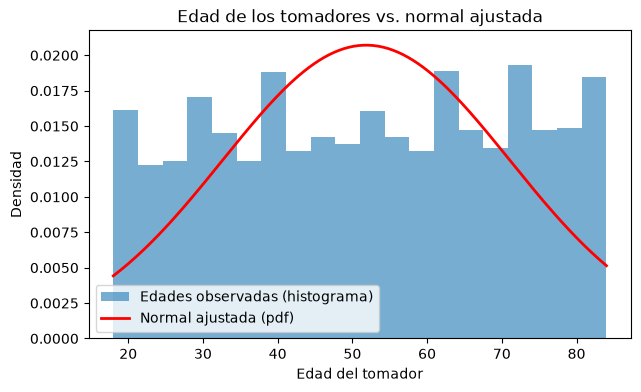

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(edades, bins=20, density=True, alpha=0.6, label="Edades observadas (histograma)")

x = np.linspace(edades.min(), edades.max(), 200)
ax.plot(x, normal_edad.pdf(x), "r-", linewidth=2, label="Normal ajustada (pdf)")

ax.set_xlabel("Edad del tomador")
ax.set_ylabel("Densidad")
ax.set_title("Edad de los tomadores vs. normal ajustada")
ax.legend()
plt.show()


### `ppf`: el inverso de la CDF

Si `cdf(x)` responde "¿qué probabilidad hay de estar por debajo de `x`?", `ppf(q)` responde la pregunta inversa: "¿qué valor `x` deja por debajo exactamente una probabilidad `q`?" — es decir, calcula percentiles a partir del modelo ajustado, en vez de directamente de los datos (como hicisteis con `np.percentile()` en el notebook anterior).


In [5]:
percentil_90_modelo = normal_edad.ppf(0.90)
percentil_90_empirico = np.percentile(edades, 90)

print(f"Percentil 90 según el modelo normal ajustado: {percentil_90_modelo:.1f} años")
print(f"Percentil 90 empírico (datos reales):          {percentil_90_empirico:.1f} años")


Percentil 90 según el modelo normal ajustado: 76.5 años
Percentil 90 empírico (datos reales):          78.0 años


### `rvs`: simular datos nuevos

`rvs(size=n)` genera `n` observaciones simuladas siguiendo la distribución. Útil para simulación Monte Carlo — p. ej. generar una cartera sintética de edades con las mismas características estadísticas que la real, para pruebas de estrés o proyecciones.


In [6]:
edades_simuladas = normal_edad.rvs(size=1000, random_state=42)
print(f"Media de la simulación: {edades_simuladas.mean():.2f} (real: {edades.mean():.2f})")
print(f"Desv. estándar simulación: {edades_simuladas.std():.2f} (real: {edades.std():.2f})")


Media de la simulación: 52.22 (real: 51.85)
Desv. estándar simulación: 18.85 (real: 19.26)


**Para ti:** calcula, con el modelo `normal_edad` ya ajustado, la probabilidad de que un tomador tenga entre 30 y 60 años (`P(30 <= edad <= 60)` — pista: es una resta de dos `.cdf()`). Compárala con la proporción empírica real usando una máscara booleana sobre `edades`.


In [7]:
# Tu código aquí


## 3. Distribución binomial: ¿cuántas pólizas se anularán este año?

La distribución **binomial** (`scipy.stats.binom`) modela el número de "éxitos" en `n` ensayos independientes, cada uno con probabilidad `p` de éxito — se parametriza con `n` (número de ensayos) y `p` (probabilidad de éxito en cada uno).

En la cartera, cada póliza tiene una probabilidad histórica de ser anulada. Si asumimos que cada póliza se anula (o no) de forma independiente con esa misma probabilidad, el número de anulaciones en un grupo de `n` pólizas nuevas sigue (aproximadamente) una binomial.


In [8]:
p_anulada = cartera["anulada"].mean()
print(f"Proporción histórica de pólizas anuladas: {p_anulada:.4f} ({p_anulada:.1%})")

n_polizas_nuevas = 20
binomial_anulaciones = scipy.stats.binom(n=n_polizas_nuevas, p=p_anulada)

# pmf: probabilidad puntual -- P(exactamente k anulaciones de 20 pólizas nuevas)
for k in range(6):
    print(f"P(exactamente {k} anulaciones) = {binomial_anulaciones.pmf(k):.4f}")


Proporción histórica de pólizas anuladas: 0.1237 (12.4%)
P(exactamente 0 anulaciones) = 0.0713
P(exactamente 1 anulaciones) = 0.2014
P(exactamente 2 anulaciones) = 0.2700
P(exactamente 3 anulaciones) = 0.2286
P(exactamente 4 anulaciones) = 0.1371
P(exactamente 5 anulaciones) = 0.0619


In [9]:
# cdf: probabilidad acumulada -- P(como mucho 3 anulaciones de 20)
prob_maximo_3 = binomial_anulaciones.cdf(3)
print(f"P(como mucho 3 anulaciones de {n_polizas_nuevas}) = {prob_maximo_3:.4f}")

# El complementario: P(más de 3 anulaciones) -- útil para dimensionar un escenario "adverso"
prob_mas_de_3 = 1 - prob_maximo_3
print(f"P(más de 3 anulaciones de {n_polizas_nuevas}) = {prob_mas_de_3:.4f}")


P(como mucho 3 anulaciones de 20) = 0.7713
P(más de 3 anulaciones de 20) = 0.2287


In [10]:
# rvs: simular 10 "años" distintos de 20 pólizas nuevas cada uno
simulaciones_anuales = binomial_anulaciones.rvs(size=10, random_state=42)
print("Anulaciones simuladas en 10 años distintos:", simulaciones_anuales)
print(f"Media de las simulaciones: {simulaciones_anuales.mean():.2f} "
      f"(esperado teórico n*p = {n_polizas_nuevas * p_anulada:.2f})")


Anulaciones simuladas en 10 años distintos: [2 5 3 3 1 1 0 4 3 3]
Media de las simulaciones: 2.50 (esperado teórico n*p = 2.47)


> 📊 En Excel esto sería `DISTR.BINOM.N(k; ensayos; prob_éxito; acumulado)`: `acumulado=FALSO` equivale a `.pmf(k)`, `acumulado=VERDADERO` equivale a `.cdf(k)`.

> ⚠️ **Error típico**: usar `n` y `p` como si fueran los parámetros de `scipy.stats.binom.rvs(n, p, size=...)` en el orden equivocado, o pasar `p` como un porcentaje entero (`12.37`) en vez de una proporción (`0.1237`). `scipy.stats` siempre espera probabilidades como valores entre 0 y 1, nunca como porcentajes.


## 4. Distribución de Poisson: número de siniestros por póliza

La distribución de **Poisson** (`scipy.stats.poisson`) modela el número de eventos que ocurren en un intervalo fijo (de tiempo, de exposición...), cuando esos eventos son relativamente raros e independientes entre sí. Es la distribución clásica para el número de siniestros por póliza y año — la base de la teoría de riesgo colectivo en tarificación.

Se parametriza con `mu` (λ, el número medio de eventos por intervalo).


In [11]:
# Número de siniestros por póliza en la cartera (0 si la póliza no tiene ningún siniestro registrado)
num_siniestros_por_poliza = (
    siniestros.groupby("poliza_id").size().reindex(cartera["poliza_id"], fill_value=0)
)

mu_siniestros = num_siniestros_por_poliza.mean()
print(f"Media de siniestros por póliza (λ): {mu_siniestros:.3f}")
print(f"Varianza de siniestros por póliza:  {num_siniestros_por_poliza.var(ddof=1):.3f}")
print("(en una Poisson teórica, media y varianza deberían ser iguales -- aquí son razonablemente cercanas)")


Media de siniestros por póliza (λ): 0.400
Varianza de siniestros por póliza:  0.446
(en una Poisson teórica, media y varianza deberían ser iguales -- aquí son razonablemente cercanas)


In [12]:
poisson_siniestros = scipy.stats.poisson(mu=mu_siniestros)

# pmf: probabilidad de tener exactamente k siniestros en el año
for k in range(5):
    print(f"P(exactamente {k} siniestros) = {poisson_siniestros.pmf(k):.4f}")

# cdf: probabilidad de tener como mucho 1 siniestro (es decir, 0 o 1)
print(f"\nP(como mucho 1 siniestro) = {poisson_siniestros.cdf(1):.4f}")

# Complementario: probabilidad de tener 2 o más siniestros (perfil de riesgo alto)
print(f"P(2 o más siniestros)     = {1 - poisson_siniestros.cdf(1):.4f}")


P(exactamente 0 siniestros) = 0.6703
P(exactamente 1 siniestros) = 0.2681
P(exactamente 2 siniestros) = 0.0536
P(exactamente 3 siniestros) = 0.0072
P(exactamente 4 siniestros) = 0.0007

P(como mucho 1 siniestro) = 0.9384
P(2 o más siniestros)     = 0.0616


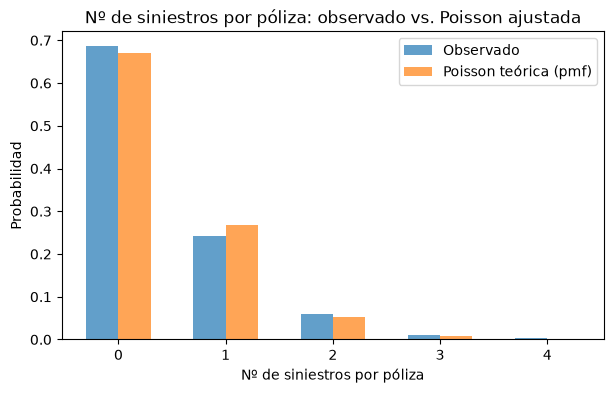

In [13]:
# Validación visual: frecuencias observadas vs. pmf teórica
frecuencias_observadas = num_siniestros_por_poliza.value_counts(normalize=True).sort_index()
k_valores = range(int(frecuencias_observadas.index.max()) + 1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([k - 0.15 for k in k_valores],
       [frecuencias_observadas.get(k, 0) for k in k_valores],
       width=0.3, label="Observado", alpha=0.7)
ax.bar([k + 0.15 for k in k_valores],
       [poisson_siniestros.pmf(k) for k in k_valores],
       width=0.3, label="Poisson teórica (pmf)", alpha=0.7)
ax.set_xlabel("Nº de siniestros por póliza")
ax.set_ylabel("Probabilidad")
ax.set_title("Nº de siniestros por póliza: observado vs. Poisson ajustada")
ax.legend()
plt.show()


**Nota sobre `.fit()` en distribuciones discretas**: a diferencia de `scipy.stats.norm`, las distribuciones discretas como `binom` o `poisson` no suelen usarse con `.fit()` en `scipy.stats` (`binom` ni siquiera lo soporta de forma útil, porque `n` normalmente es un dato conocido del diseño del experimento, no algo que se estime). El patrón habitual es estimar el parámetro directamente por su definición estadística — la media muestral para `mu` en Poisson, la proporción de éxitos para `p` en binomial — tal como habéis hecho aquí.

**Para ti:** con `poisson_siniestros` ya ajustada, calcula la probabilidad de que una póliza tenga **entre 1 y 3 siniestros, ambos incluidos** (`P(1 <= X <= 3)`). Hazlo de dos formas y comprueba que dan el mismo resultado: (a) sumando `.pmf(1) + .pmf(2) + .pmf(3)`, y (b) con una resta de dos `.cdf()`.


In [14]:
# Tu código aquí


## Resumen

- `scipy.stats` expone una API uniforme para cualquier distribución: `.pdf()`/`.pmf()` (densidad o probabilidad puntual), `.cdf()` (acumulada), `.ppf()` (inversa de la acumulada, percentiles) y `.rvs()` (simulación).
- Se puede "congelar" una distribución con sus parámetros (`d = scipy.stats.norm(loc=..., scale=...)`) y reutilizarla en varias llamadas, en vez de repetir los parámetros cada vez.
- **Normal** (continua, `loc`/`scale`): apropiada para variables continuas simétricas, como la edad de los tomadores. `.fit(datos)` estima los parámetros por máxima verosimilitud — pero un ajuste sin error no significa un buen ajuste; hay que validarlo contra los datos reales.
- **Binomial** (discreta, `n`/`p`): número de éxitos en `n` ensayos independientes con probabilidad `p` — por ejemplo, número de pólizas anuladas de un lote de `n` pólizas nuevas.
- **Poisson** (discreta, `mu`): número de eventos raros e independientes en un intervalo fijo — el modelo clásico para el número de siniestros por póliza y año.
- Las distribuciones discretas normalmente no se ajustan con `.fit()`: sus parámetros se estiman directamente de su definición estadística (media muestral para `mu`, proporción de éxitos para `p`).
- Nunca deis por bueno un ajuste de distribución solo porque el código se ejecutó sin error: comparad siempre la probabilidad teórica contra la proporción empírica observada, o visualmente contra un histograma.

**Siguiente:** `06_teoria_pruebas_hipotesis.ipynb` — pruebas de hipótesis (t-test, chi-cuadrado) y cómo traducir un resultado estadístico a lenguaje de negocio sin perder rigor.
